# Household Energy Consumption - Evaluation & Model Comparison

This notebook loads the exported predictions and feature importances to perform systematic evaluation, model comparison, trade-off analysis, and extract actionable business insights.

## Setup and Library Imports

We import data handling tools (`pandas`, `numpy`), visualization tools (`matplotlib.pyplot`), and error calculation metrics (`sklearn.metrics`).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline

## Load Predictions and Feature Importances

We load the outputs exported during the modeling step.

In [2]:
predictions_df = pd.read_csv(
    r"C:\Users\Waleed Qamar\Downloads\energy-forecasting\data\model_predictions.csv",
    parse_dates=["Datetime"],
    index_col="Datetime"
)

importance = pd.read_csv(
    r"C:\Users\Waleed Qamar\Downloads\energy-forecasting\data\xgboost_feature_importances.csv",
    index_col=0
)["0"]

## Evaluation Metrics Definition

We define a function to compute:
1. **Mean Absolute Error (MAE)**: Measures the average magnitude of absolute errors (easy to interpret direct scale).
2. **Root Mean Squared Error (RMSE)**: Penalizes larger prediction errors heavily since errors are squared before averaging.

In [3]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

### Calculate Error Metrics for All Models

We evaluate the forecast quality of ARIMA, Prophet, and XGBoost on the test sequence.

In [4]:
arima_mae, arima_rmse = evaluate(predictions_df["Actual"], predictions_df["ARIMA_Forecast"])
prophet_mae, prophet_rmse = evaluate(predictions_df["Actual"], predictions_df["Prophet_Forecast"])
xgb_mae, xgb_rmse = evaluate(predictions_df["Actual"], predictions_df["XGBoost_Forecast"])

results = pd.DataFrame({
    "MAE": [arima_mae, prophet_mae, xgb_mae],
    "RMSE": [arima_rmse, prophet_rmse, xgb_rmse]
}, index=["ARIMA", "Prophet", "XGBoost"])

results

,MAE,RMSE
ARIMA,0.675540,0.823778
Prophet,0.548550,0.701401
XGBoost,0.361359,0.528593


## Visualizing Forecast vs Actual Consumption

We plot the model predictions alongside the actual test readings to evaluate how well each model tracks the peaks, valleys, and diurnal seasonality of household energy demand.

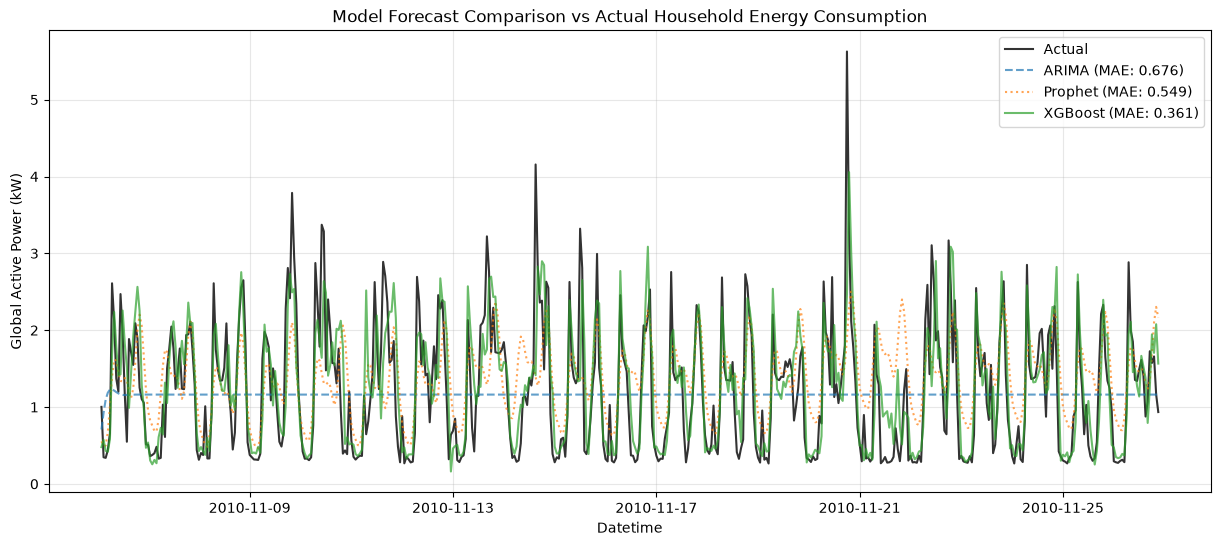

In [5]:
plt.figure(figsize=(15,6))
plt.plot(predictions_df.index, predictions_df["Actual"], label="Actual", alpha=0.8, color='black')
plt.plot(predictions_df.index, predictions_df["ARIMA_Forecast"], label=f"ARIMA (MAE: {arima_mae:.3f})", alpha=0.7, linestyle='--')
plt.plot(predictions_df.index, predictions_df["Prophet_Forecast"], label=f"Prophet (MAE: {prophet_mae:.3f})", alpha=0.7, linestyle=':')
plt.plot(predictions_df.index, predictions_df["XGBoost_Forecast"], label=f"XGBoost (MAE: {xgb_mae:.3f})", alpha=0.7)

plt.title("Model Forecast Comparison vs Actual Household Energy Consumption")
plt.ylabel("Global Active Power (kW)")
plt.xlabel("Datetime")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('../images/Model Forecast Comparison vs Actual Household Energy Consumption.png', bbox_inches='tight')
plt.show()

## Feature Importance analysis (XGBoost)

We inspect which features XGBoost relied on most to make forecasts. This validates if features align with physical reality (e.g. preceding hour or day's consumption having high predictive value).

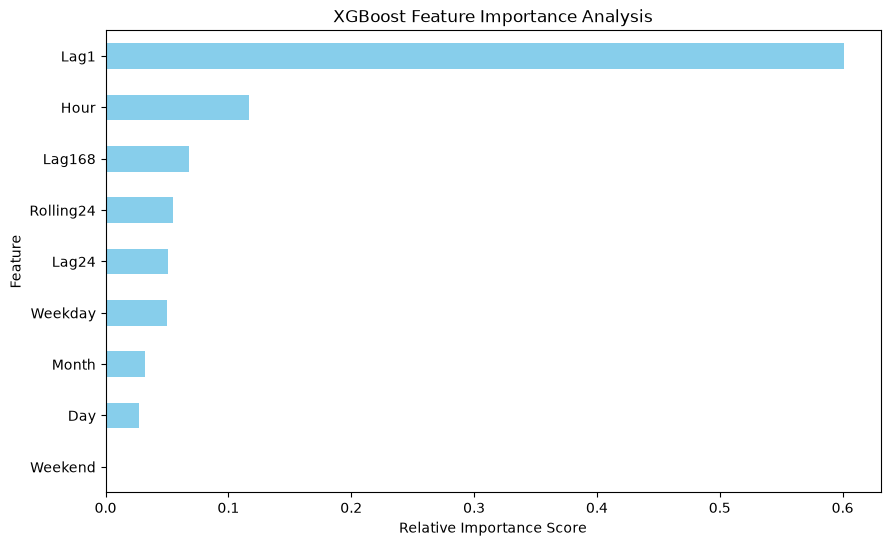

In [6]:
plt.figure(figsize=(10,6))
importance.sort_values().plot.barh(color='skyblue')
plt.title("XGBoost Feature Importance Analysis")
plt.xlabel("Relative Importance Score")
plt.ylabel("Feature")
plt.savefig('../images/XGBoost Feature Importance Analysis.png', bbox_inches='tight')
plt.show()

## Model Comparison and Trade-offs

| Criteria | ARIMA | Prophet | XGBoost |
|---|---|---|---|
| **Trend** | ✓ | ✓ | ✓ (learned via features) |
| **Seasonality** | Manual configuration | Automatic detection | Via temporal & lag features |
| **Feature Support** | No external features | Limited covariates | Excellent support |
| **Speed** | Medium | Medium | Fast (highly scalable) |
| **Accuracy** | Moderate | Good | Often Best (given enough features) |

### Trade-offs Discussion:
- **ARIMA** performs moderately well for very short-term prediction but degrades over longer horizons as it depends heavily on manual parameter tuning (p, d, q) and does not easily support complex exogenous signals or multiple seasonalities (e.g., hourly and daily combined).
- **Prophet** requires very little tuning to capture multiple nested seasonalities (daily, weekly, yearly) and structural trends, making it highly robust and user-friendly for business applications.
- **XGBoost** is extremely flexible and provides high forecasting precision. However, it requires careful feature engineering (generating lags, rolling windows, and time indicators) to represent temporal relationships since it does not have a native representation of time.

## Business Insights & Recommendations

1. **Strong Temporal Patterns**: Household energy usage follows strong hourly (peak times around evening) and weekly patterns (different demand profiles on weekends).
2. **Autoregressive Predictive Power**: The most predictive feature for energy usage is the immediate prior consumption (`Lag1`), followed by the consumption at the same hour on the previous day (`Lag24`).
3. **Grid Load Balancing**: Utility operators can deploy XGBoost-based forecasting systems to anticipate demand spikes 24-hours in advance and allocate power generation resources efficiently, reducing operational costs.
4. **Smart Appliance Scheduling**: Intelligent home automation systems can schedule heavy energy consumers (such as heating systems or EV charging) during forecasted off-peak hours to save on electricity bills and stabilize the grid.